# Panorama global de ciberataques y vulnerabilidades (2015-2025)

Cuaderno de desarrollo del caso práctico de **Visualización de Datos** (Máster en
Ingeniería y Ciencia de Datos, UNED). Recorre el trabajo completo en el orden en
que se hizo. Primero cargamos y preprocesamos las fuentes desde su capa cruda,
después exploramos cada una por separado, seleccionamos las que aportan al
objetivo, aplicamos la ingeniería de características que las conecta, generamos el
catálogo de visualizaciones combinadas y, a partir de ese catálogo, planteamos el
storytelling que estructura el dashboard.

Cada decisión se justifica en las celdas de texto apoyándose en la teoría de la
asignatura. Reutilizamos las funciones del
paquete `src/` en modo lectura, sin duplicar lógica y sin escribir en disco, de
modo que el cuaderno reproduce en memoria exactamente lo mismo que el pipeline
`make preprocess` deja en `data/processed/`.


## Objetivo y público

El objetivo global es transformar tres tipos de evidencia heterogénea
(vulnerabilidades técnicas, incidentes documentados e impacto materializado) en
una lectura comprensible del panorama de ciberseguridad de la última década. El
detonante es la dificultad de interpretar sin herramientas analíticas el volumen
creciente de datos de seguridad (Tema 1.4.2, el objetivo nace de una razón y de un
efecto esperado). La audiencia es doble, perfiles técnicos que priorizan defensa y
responsables que deciden inversión, lo que fija una función analítica y un tono
sobrio (Tema 1.4.2, la audiencia define función y tono).

## Preguntas de investigación

1. ¿Cómo evolucionan el volumen y la gravedad de las CVEs publicadas?
2. ¿Qué tipos de debilidad (CWE) concentran las vulnerabilidades y son los más frecuentes también los más graves?
3. ¿Dónde se concentra geográficamente la actividad documentada?
4. ¿Qué relación existe entre categoría de ataque y sector objetivo?
5. ¿Existe estacionalidad en la publicación de vulnerabilidades?
6. ¿Coincide la gravedad teórica (CVSS) con la probabilidad y la explotación real (EPSS, KEV)?
7. ¿Qué escala de usuarios afectados tiene cada sector y cada año?
8. ¿Cuál es la dimensión económica del ransomware?

In [1]:
import datetime
import json
import pathlib
import sys

import altair as alt
import pandas as pd

PROJECT_ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils import config
from src.preprocessing import cleaning, enrichment, integration, run
from src.preprocessing.taxonomies import CWE_UNKNOWN
from src.visualization import charts, dashboard, theme
from src.visualization.theme import register_theme

# Figuras vectoriales embebidas en el propio .ipynb. El renderizador por
# defecto guarda un contenedor que descarga Vega de un CDN, de modo que el
# cuaderno solo se ve con conexión, y la entrega tiene que ser autocontenida.
# Va antes del tema porque enable() descarta las opciones de incrustación, y
# entre ellas viaja la configuración regional de los números.
alt.renderers.enable("svg")

register_theme()  # variante clara, adecuada para el fondo blanco del cuaderno
alt.data_transformers.disable_max_rows()

RAW = config.DATA_RAW_DIR
PROCESSED = config.DATA_PROCESSED_DIR
print("Raíz del proyecto:", PROJECT_ROOT.name)

Raíz del proyecto: ciberataques


## Sistema de color

Trabajamos con una **paleta única** de la familia índigo, en tonalidades apagadas, en
lugar de dos rampas de significados opuestos. El color es poco preciso para
cuantitativas y eficaz para ordinales y categóricas (Cuadro 3.1 de Mazza), así que lo
reservamos para el significado y no para la magnitud exacta.

- **Rampa secuencial de un solo tono**, índigo de claro a oscuro, para la magnitud y
  la actividad (conteos, mapas, celdas), donde no hace falta distinguir categorías,
  solo intensidad (intensidad para cuantitativa, Mazza).
- **Gradiente de cuatro pasos, índigo a cálido**, para la severidad ordinal (barras y
  áreas por banda CVSS). Un único tono puro apenas se distingue en marcas contiguas
  pequeñas; virar hacia el cálido en el extremo crítico separa mejor los cuatro niveles
  sin perder el orden perceptivo ni salir de la familia (intensidad y tono conjugados
  para ordinal, Mazza), y adelanta el acento cálido que reservamos para lo crítico.
- **Acento índigo medio** para las series simples (barras, burbujas, pagos), donde la
  longitud o el área codifican el valor.
- **Acento cálido de contraste**, naranja a rosa, reservado a lo excepcional que debe
  resaltar, las vulnerabilidades explotadas y su uso en ransomware. Al ser el
  complementario cálido de la familia fría, crea dominancia por contraste sin romper la
  unidad (contraste y dominancia, Tema 3.3), y se usa con moderación.
- **Set cualitativo** de la misma familia extendida hacia el cálido para las variables
  nominales (fuente, tipo de actor), el canal de tono adecuado para categóricas.
- **Gris neutro** para el contexto y la ausencia de dato, y una **escala divergente**
  índigo a rojo reservada para comparaciones respecto a un valor de referencia.

Ningún esquema se reutiliza con otro significado, y la paleta actúa de hilo conductor
entre figuras (similitud, Gestalt). Vive en `src/visualization/theme.py`, de modo que el
cuaderno, la app y las figuras exportadas comparten exactamente los mismos valores;
el dashboard usa su variante oscura, donde la rampa se invierte en luminosidad para que
más brillo siga significando más valor.

In [2]:
# La paleta vive en src/visualization/theme.py y la comparten el cuaderno, la app
# y las figuras exportadas. register_theme() ya ha fijado la variante clara.
paleta = pd.DataFrame(
    [
        ("Magnitud y actividad", " ".join(theme.activity_scale().range)),
        ("Severidad ordinal", " ".join(theme.SEVERITY_COLORS)),
        ("Acento de serie simple", f"{theme.ACCENT_COLOR} / {theme.ACCENT_STROKE}"),
        ("Explotación confirmada", f"{theme.KEV_COLOR} / {theme.KEV_RANSOMWARE_COLOR}"),
        ("Nominal (tono)", " ".join(theme.CATEGORICAL_COLORS[:6])),
        ("Contexto y sin dato", f"{theme.NEUTRAL_GRAY} / {theme.NO_DATA_COLOR}"),
    ],
    columns=["Uso", "Colores"],
)
paleta

,Uso,Colores
0,Magnitud y actividad,#c6ceff #a2adea #7e8cd5 #596dc0 #2c50ab
1,Severidad ordinal,#485ea1 #8d5eb1 #cd56a6 #fc5983
2,Acento de serie simple,#485ea1 / #2c50ab
3,Explotación confirmada,#eb9800 / #fc5983
4,Nominal (tono),#485ea1 #e69f00 #009e73 #d55e00 #56b4e9 #cc79a7
5,Contexto y sin dato,#94a3b8 / #e5e7eb


## 1. Carga y preprocesado desde el crudo

El preprocesado busca aumentar la relación señal-ruido antes de analizar, agrupando,
filtrando y transformando (Tema 2.2.1). Trabajamos sobre la metodología en espiral
(Tema 2.2), partiendo de `data/raw/` y aplicando en cada fuente las mismas rutinas
de `src/preprocessing/` que usa el pipeline de producción. Mostramos los conteos
antes y después de cada decisión para dejarla trazada. No escribimos nada, todo se
reproduce en memoria.

Esta sección es la única que lee de `data/raw/`, que no viaja en el repositorio por tamaño (unos 145 MB) y se regenera con `make data-all`. Las salidas quedan guardadas para poder leerla sin ejecutarla; a partir de la sección 2 basta con los datasets de `data/processed/`, que sí están incluidos.

### 1.1 Vulnerabilidades NVD

Partimos del volcado de la API v2 de NVD. Descartamos las CVEs con estado
`Rejected` porque son entradas retiradas que no describen una vulnerabilidad real
(limpieza de datos, Tema 2.2.1). Acotamos al periodo 2015-2025 fijado en
`config.py`, unificamos la debilidad ausente bajo una etiqueta común y derivamos la
banda de severidad aplicando los umbrales CVSS v3 a todo el histórico, de modo que
las puntuaciones antiguas en v2 comparten la misma escala ordinal. Imputamos el
CVSS ausente por la media de su CWE y marcamos esas filas con `cvss_imputed`, para
que cualquier análisis pueda excluirlas (imputación de datos frente a eliminación,
Tema 2.2.1).

In [3]:
# La capa cruda no viaja en el repositorio (unos 145 MB). Si falta, este aviso
# sustituye al error de fichero no encontrado y dice cómo regenerarla.
if not (RAW / "nvd" / "nvd_cves.parquet").exists():
    raise FileNotFoundError(
        "Falta data/raw/. Regenérala con `make data-all` para ejecutar la sección 1, "
        "o continúa desde la sección 2, que solo usa data/processed/."
    )
print("Capa cruda disponible en", RAW)

Capa cruda disponible en /mnt/e/Documents/01 Estudios/02 Universidad/02 UNED - Master IyCD/01 Curso 2025-2026/08 Visualización de Datos/02 CASO PRÁCTICO/ciberataques/data/raw


In [4]:
nvd_raw = pd.read_parquet(RAW / "nvd" / "nvd_cves.parquet")
print(f"NVD crudo                {len(nvd_raw):>10,}")

vuln = nvd_raw[nvd_raw["vuln_status"] != "Rejected"].copy()
print(f"Tras excluir Rejected    {len(vuln):>10,}  (-{len(nvd_raw) - len(vuln):,})")

vuln = cleaning.normalize_dates(vuln, "published")
vuln = cleaning.filter_date_range(vuln, "published", config.ANALYSIS_START_YEAR, config.ANALYSIS_END_YEAR)
print(f"Tras filtro 2015-2025    {len(vuln):>10,}")

vuln["year"] = vuln["published"].dt.year.astype(int)
vuln["month"] = vuln["published"].dt.month.astype(int)
vuln["cwe_id"] = vuln["cwe_id"].where(vuln["cwe_id"].astype(str).str.startswith("CWE-"), CWE_UNKNOWN)
vuln = cleaning.impute_missing_cvss(vuln, "cwe_id", "cvss_score").rename(columns={"cvss_score_imputed": "cvss_imputed"})
vuln = cleaning.derive_severity_from_score(vuln, "cvss_score", "cvss_severity")
print(f"CVSS imputado            {vuln['cvss_imputed'].mean() * 100:>9.1f}%")

NVD crudo                   257,545
Tras excluir Rejected       241,888  (-15,657)
Tras filtro 2015-2025       241,888


CVSS imputado                  1.5%


Enriquecemos NVD con dos fuentes que comparten la clave `cve_id`. El catálogo KEV
de CISA aporta la explotación confirmada (`is_kev`) y su uso en campañas de
ransomware (`kev_ransomware`); EPSS aporta la probabilidad estimada de explotación.
Este cruce es una transformación que genera atributos nuevos a partir de fuentes
externas (Tema 2.2.1), y habilita más adelante el contraste entre gravedad teórica
y explotación real.

In [5]:
kev_catalog = json.loads((RAW / "kev" / "kev_catalog.json").read_text(encoding="utf-8"))
vuln = enrichment.add_kev_flags(vuln, kev_catalog)
epss_raw = pd.read_csv(RAW / "epss" / "epss_scores-current.csv.gz", comment="#")
vuln = enrichment.add_epss_scores(vuln, epss_raw)
vuln = vuln[run.VULNERABILITY_COLUMNS]
print(f"vulnerabilities          {vuln.shape}")
print(f"Explotadas (KEV)         {int(vuln['is_kev'].sum()):>10,}  (ransomware {int(vuln['kev_ransomware'].sum()):,})")
vuln.head(3)

vulnerabilities          (241888, 16)
Explotadas (KEV)              1,395  (ransomware 302)


,cve_id,published,year,month,cvss_score,cvss_imputed,cvss_severity,cvss_version,attack_vector,cwe_id,cpe_count,is_kev,kev_date_added,kev_ransomware,epss_score,epss_percentile
0,CVE-2011-5285,2015-01-01 02:59:01.533,2015,1,4.3,False,MEDIUM,2.0,NETWORK,CWE-79,1,False,NaT,False,0.00966,0.57548
1,CVE-2011-5286,2015-01-01 02:59:02.783,2015,1,7.5,False,HIGH,2.0,NETWORK,CWE-89,1,False,NaT,False,0.03032,0.85925
2,CVE-2011-5287,2015-01-01 02:59:03.783,2015,1,4.3,False,MEDIUM,2.0,NETWORK,CWE-79,1,False,NaT,False,0.00966,0.57547


### 1.2 Incidentes VCDB y EuRepoC

VCDB (formato VERIS, sesgo estadounidense) y EuRepoC (foco europeo, con atribución)
describen la misma clase de objeto, un incidente, con vocabularios distintos. Los
llevamos a un esquema común de fecha, país ISO 3166, sector y categoría de ataque
primaria, y los concatenamos con una columna `source` que preserva la procedencia.
Combinar dos fuentes en una entidad más abstracta es la operación de integración de
la teoría (Tema 2.2.2, combinar información). La resolución de país a códigos ISO
prepara la dimensión geoespacial.

In [6]:
vcdb_raw = pd.read_parquet(RAW / "vcdb" / "vcdb_incidents.parquet")
eurepoc_raw = pd.read_csv(RAW / "eurepoc" / "eurepoc_global_dataset_1_3.csv", low_memory=False)
print(f"VCDB crudo {len(vcdb_raw):,}  |  EuRepoC crudo {len(eurepoc_raw):,}")

incidents = integration.merge_sources(
    integration.prepare_vcdb_incidents(vcdb_raw),
    integration.prepare_eurepoc_incidents(eurepoc_raw),
)
print(f"Incidentes unificados {incidents.shape}")
print(incidents["source"].value_counts().to_string())
incidents.head(3)

VCDB crudo 10,042  |  EuRepoC crudo 3,414
Incidentes unificados (7007, 14)
source
VCDB       4356
EuRepoC    2651


,source,incident_id,date,year,month,country_iso2,country_name,country_numeric,sector,attack_category,incident_type_raw,actor_raw,weighted_intensity,title
0,VCDB,0eb22d90-8e87-11ec-a600-657ec2694f8f,2020-01-01,2020,1,ES,Spain,724,Servicios profesionales,Error,error,internal,<NA>,Presitge Software accidently misconfigured the...
1,VCDB,9eda6e80-de98-11e7-9424-7b935f12be98,2017-02-01,2017,2,US,United States,840,Salud,Hacking,hacking,external,<NA>,Officials say an employee database was hacked ...
2,VCDB,da0b05e0-ad29-11e8-9e5a-c1f99505e93a,2018-02-01,2018,2,US,United States,840,Administración pública,Uso indebido,misuse;physical,external;partner,<NA>,The Wisconsin Department of Health Services (D...


### 1.3 Brechas Have I Been Pwned

Nos quedamos con las brechas genuinas, excluyendo las marcadas por el propio
servicio como fabricadas, listas de spam, volcados de stealer o retiradas, porque
distorsionarían el recuento de impacto. Acotamos por fecha e inferimos el sector a
partir del dominio, el título y la descripción, creando una variable categórica a
partir de texto libre (transformación de variables, Tema 2.2.1). Reutilizamos la
función de inferencia del pipeline para no duplicar el mapa de palabras clave.

In [7]:
hibp_raw = pd.DataFrame(json.loads((RAW / "hibp" / "breaches.json").read_text(encoding="utf-8")))
print(f"HIBP crudo               {len(hibp_raw):>7,}")

genuine = ~(hibp_raw["IsFabricated"] | hibp_raw["IsSpamList"] | hibp_raw["IsStealerLog"] | hibp_raw["IsRetired"])
hb = cleaning.normalize_dates(hibp_raw[genuine], "BreachDate")
hb = cleaning.filter_date_range(hb, "BreachDate", config.ANALYSIS_START_YEAR, config.ANALYSIS_END_YEAR)
hb["sector"] = hb.apply(lambda row: run._infer_hibp_sector(row["Title"], row["Domain"], row["Description"]), axis=1)
breaches = pd.DataFrame({
    "name": hb["Name"],
    "title": hb["Title"],
    "domain": hb["Domain"],
    "date": hb["BreachDate"],
    "year": hb["BreachDate"].dt.year.astype(int),
    "pwn_count": hb["PwnCount"],
    "sector": hb["sector"],
    "is_verified": hb["IsVerified"],
    "is_sensitive": hb["IsSensitive"],
    "data_classes": hb["DataClasses"].map(lambda values: ";".join(values)),
})
print(f"Brechas genuinas 2015-25 {len(breaches):>7,}  (-{int((~genuine).sum()):,} no genuinas)")
breaches.head(3)

HIBP crudo                 1,016
Brechas genuinas 2015-25     797  (-27 no genuinas)


,name,title,domain,date,year,pwn_count,sector,is_verified,is_sensitive,data_classes
0,000webhost,000webhost,000webhost.com,2015-03-01,2015,14936670,Tecnología e información,True,False,Email addresses;IP addresses;Names;Passwords
1,123RF,123RF,123rf.com,2020-03-22,2020,8661578,Medios y entretenimiento,True,False,Email addresses;IP addresses;Names;Passwords;P...
3,17Media,17,17app.co,2016-04-19,2016,4009640,Medios y entretenimiento,True,False,Device information;Email addresses;IP addresse...


### 1.4 Pagos de ransomware Ransomwhere

El fichero original agrupa las transacciones por dirección de monedero.
Lo aplanamos a un pago verificado por fila, conservando familia, cadena, importe en
dólares y fecha, y acotamos al periodo. Esta desagregación cambia el grano de
análisis de monedero a transacción, el nivel adecuado para estudiar el fenómeno
económico.

In [8]:
payload = json.loads((RAW / "ransomwhere" / "payments.json").read_text(encoding="utf-8"))
addresses = payload.get("result", payload) if isinstance(payload, dict) else payload
rows = []
for entry in addresses:
    for transaction in entry.get("transactions", []):
        timestamp = transaction.get("time")
        if not timestamp:
            continue
        rows.append({
            "date": datetime.datetime.fromtimestamp(timestamp, tz=datetime.timezone.utc),
            "family": entry.get("family"),
            "blockchain": entry.get("blockchain"),
            "amount_usd": transaction.get("amountUSD"),
        })
payments = pd.DataFrame(rows)
payments["date"] = payments["date"].dt.tz_localize(None)
payments["year"] = payments["date"].dt.year
payments = cleaning.filter_date_range(payments, "year", config.ANALYSIS_START_YEAR, config.ANALYSIS_END_YEAR)
print(f"Direcciones {len(addresses):,}  ->  pagos verificados {len(payments):,}")
payments.head(3)

Direcciones 11,186  ->  pagos verificados 20,939


,date,family,blockchain,amount_usd,year
0,2020-04-25 18:24:13,Netwalker (Mailto),bitcoin,3298.821426,2020
1,2020-04-17 23:13:05,Netwalker (Mailto),bitcoin,5897.526734,2020
2,2020-06-10 21:22:06,Netwalker (Mailto),bitcoin,8161.457361,2020


### 1.5 Agregado mensual y comprobación de consistencia

Construimos el agregado mensual de CVEs por severidad, que alimenta las series
temporales sin enviar al navegador las 242k filas (agregación, Tema 2.2.1). Después
comparamos los conteos reproducidos en memoria con los parquet de
`data/processed/`. Coincidir confirma que el cuaderno reproduce el pipeline sin
divergencias y que no dependemos de datos preexistentes.

In [9]:
monthly = (
    vuln.groupby(["year", "month", "cvss_severity", "is_kev"], observed=True)
    .agg(cve_count=("cve_id", "count"), epss_mean=("epss_score", "mean"))
    .reset_index()
)

data = {
    "vulnerabilities": vuln,
    "monthly": monthly,
    "incidents": incidents,
    "breaches": breaches,
    "payments": payments,
}

files = {
    "vulnerabilities": "vulnerabilities.parquet",
    "monthly": "vulnerabilities_monthly.parquet",
    "incidents": "incidents.parquet",
    "breaches": "breaches.parquet",
    "payments": "ransomware_payments.parquet",
}
check = pd.DataFrame({
    "reproducido": {name: len(df) for name, df in data.items()},
    "processed": {name: len(pd.read_parquet(PROCESSED / files[name])) for name in data},
})
check["coincide"] = check["reproducido"] == check["processed"]
check

,reproducido,processed,coincide
vulnerabilities,241888,241888,True
monthly,855,855,True
incidents,7007,7007,True
breaches,797,797,True
payments,20939,20939,True


## 2. Exploración de cada fuente

Antes de combinar, exploramos cada fuente por separado. Para cada una describimos su
estructura con el flujo de la asignatura, primeras filas, tipos y nulos, resumen
estadístico y recuento de las categóricas clave (Tema 2.3), y cerramos con una
representación individual que revela su forma y sus valores atípicos (exploración,
Tema 1.4.1). Agregamos en pandas para dibujar solo las marcas necesarias, usamos la
posición y la longitud, los canales más precisos para cuantitativas (Cuadro 3.1 de
Mazza), y reservamos el tono para la única variable nominal presente, la fuente del
incidente.

### 2.1 Vulnerabilidades

El resumen de nulos confirma que solo la versión y el vector de ataque tienen
ausencias (las CVEs antiguas sin bloque CVSS v3), y que el CVSS quedó completo tras
la imputación. La distribución por banda muestra que la severidad media domina y la
crítica es minoritaria. El vector `NETWORK` concentra la mayoría, lo que sitúa el
riesgo en la exposición remota. En el top de CWE, frecuencia y gravedad media no
coinciden, una señal que exploramos en las visualizaciones combinadas.

In [10]:
resumen = pd.DataFrame({
    "no_nulos": vuln.notna().sum(),
    "pct_nulos": (vuln.isna().mean() * 100).round(1),
    "dtype": vuln.dtypes.astype(str),
})
resumen

,no_nulos,pct_nulos,dtype
cve_id,241888,0.0,str
published,241888,0.0,datetime64[us]
year,241888,0.0,int64
month,241888,0.0,int64
cvss_score,241888,0.0,float64
cvss_imputed,241888,0.0,bool
cvss_severity,241888,0.0,object
cvss_version,238346,1.5,str
attack_vector,238346,1.5,str
cwe_id,241888,0.0,str


In [11]:
print(vuln[["cvss_score", "epss_score", "cpe_count"]].describe().round(3).to_string())
print()
print("Banda de severidad")
print(vuln["cvss_severity"].value_counts().reindex(["LOW", "MEDIUM", "HIGH", "CRITICAL"]).to_string())
print()
print("Vector de ataque")
print(vuln["attack_vector"].value_counts(dropna=False).to_string())

       cvss_score  epss_score   cpe_count
count  241888.000  241888.000  241888.000
mean        7.053       0.026       8.510
std         1.704       0.093      46.719
min         0.000       0.000       0.000
25%         5.500       0.003       1.000
50%         7.200       0.007       1.000
75%         8.200       0.015       4.000
max        10.000       1.000    5821.000

Banda de severidad
cvss_severity
LOW           5241
MEDIUM      107683
HIGH         94358
CRITICAL     34606

Vector de ataque
attack_vector
NETWORK             174264
LOCAL                56511
ADJACENT_NETWORK      5386
NaN                   3542
PHYSICAL              2185


In [12]:
por_anno = pd.crosstab(vuln["year"], vuln["cvss_severity"], normalize="index") * 100
por_anno = por_anno[["LOW", "MEDIUM", "HIGH", "CRITICAL"]].round(1)
por_anno.insert(0, "CVEs", vuln.groupby("year").size())
por_anno

cvss_severity,CVEs,LOW,MEDIUM,HIGH,CRITICAL
year,,,,,
2015,6494,9.1,53.9,19.3,17.6
2016,6449,3.4,37.9,44.8,13.9
2017,14642,1.6,38.9,45.0,14.4
2018,16510,1.0,37.6,45.7,15.7
2019,17305,1.8,41.3,41.7,15.2
2020,18322,2.3,41.0,41.9,14.8
2021,20149,2.2,42.1,42.5,13.2
2022,25074,2.0,40.6,40.5,16.9
2023,28817,1.5,44.5,38.0,16.1


In [13]:
top_cwe = (
    vuln[vuln["cwe_id"] != "Unknown"]
    .groupby("cwe_id")
    .agg(cves=("cve_id", "count"), cvss_medio=("cvss_score", "mean"), epss_medio=("epss_score", "mean"))
    .nlargest(10, "cves")
    .round(3)
)
top_cwe

,cves,cvss_medio,epss_medio
cwe_id,,,
CWE-79,35346,5.798,0.013
CWE-89,12338,8.707,0.029
CWE-787,11985,7.978,0.029
CWE-20,7747,7.131,0.033
CWE-125,7687,6.758,0.019
CWE-352,7645,7.010,0.006
CWE-119,7235,8.017,0.050
CWE-200,6916,5.842,0.029
CWE-862,6134,6.145,0.010


**Representación individual.** Histograma del CVSS, la representación estándar de la
distribución de una cuantitativa continua. La forma multimodal refleja los cortes de
banda y muestra que la masa se acumula en el tramo medio-alto, no en el crítico.

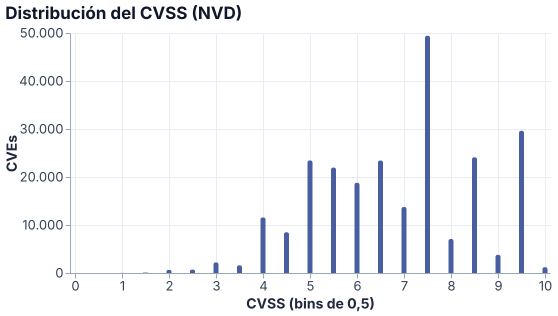

In [14]:
paso = 0.5
hist = (vuln.assign(bin=(vuln["cvss_score"] // paso) * paso)
        .groupby("bin").size().reset_index(name="cves"))
alt.Chart(hist).mark_bar(color=theme.ACCENT_COLOR).encode(
    x=alt.X("bin:Q", title="CVSS (bins de 0,5)", scale=alt.Scale(domain=[0, 10])),
    y=alt.Y("cves:Q", title="CVEs"),
    tooltip=[alt.Tooltip("bin:Q", title="CVSS"), alt.Tooltip("cves:Q", title="CVEs", format=",")],
).properties(width=480, height=240, title="Distribución del CVSS (NVD)")

### 2.2 Incidentes

La cobertura temporal por fuente tiene forma de U. VCDB aporta el grueso hasta 2017
y decae tras 2020; EuRepoC crece y sostiene los años recientes hasta 2024. Esta
complementariedad justifica integrarlas. El sector y la categoría de ataque quedan
poblados en la taxonomía común de once clases, y la atribución de actor solo existe
en EuRepoC. Estados Unidos domina el recuento por país, en parte por el sesgo de
reporte de VCDB, algo que declararemos al interpretar el mapa.

In [15]:
print(f"Incidentes            {len(incidents):>8,}")
print(f"País resuelto         {incidents['country_iso2'].notna().mean() * 100:>7.1f}%")
print(f"Países distintos      {incidents['country_iso2'].nunique():>8}")
print()
print(incidents["source"].value_counts().to_string())

Incidentes               7,007
País resuelto            95.2%
Países distintos           153

source
VCDB       4356
EuRepoC    2651


In [16]:
pd.crosstab(incidents["year"], incidents["source"], margins=True, margins_name="Total")

source,EuRepoC,VCDB,Total
year,,,
2015,131,924,1055
2016,166,843,1009
2017,135,603,738
2018,120,343,463
2019,91,333,424
2020,71,311,382
2021,160,117,277
2022,354,6,360
2023,723,749,1472


In [17]:
print("Sector por fuente")
print(pd.crosstab(incidents["sector"], incidents["source"], margins=True, margins_name="Total")
      .sort_values("Total", ascending=False).head(12).to_string())
print()
print("Categoría de ataque")
print(incidents["attack_category"].value_counts().to_string())

Sector por fuente
source                             EuRepoC  VCDB  Total
sector                                                 
Total                                 2651  4356   7007
Administración pública                1219   618   1837
Salud                                    0  1030   1030
Infraestructura crítica y energía      924    84   1008
Educación y ciencia                     18   844    862
Servicios profesionales                155   327    482
Comercio y hostelería                    0   397    397
Finanzas                                 0   393    393
Tecnología e información                 0   386    386
Otros / Desconocido                    266   116    382
Medios y entretenimiento                69    50    119
Industria                                0   111    111

Categoría de ataque
attack_category
Hacking              1803
Error                 994
Robo de datos         929
Disrupción            766
Uso indebido          576
Ransomware            492
Físic

El recuento por sector y ataque esconde un efecto de agregación que conviene medir antes de sacar conclusiones. Comprobamos si alguna celda depende de un único evento.

In [18]:
celda = incidents[(incidents["sector"] == "Educación y ciencia")
                  & (incidents["attack_category"] == "Hacking")]
moveit = celda["title"].str.contains("MOVEit", case=False, na=False)
print(f"Celda Educación y ciencia × Hacking   {len(celda):>5,}")
print(f"  de ellos, campaña MOVEit (2023)     {int(moveit.sum()):>5,} ({moveit.mean() * 100:.0f} %)")
print(f"  resto, repartido en la década       {int((~moveit).sum()):>5,}")
print("\nIncidentes de VCDB por año")
print(incidents[incidents["source"] == "VCDB"].groupby("year").size().to_string())

Celda Educación y ciencia × Hacking     694
  de ellos, campaña MOVEit (2023)       612 (88 %)
  resto, repartido en la década          82

Incidentes de VCDB por año
year
2015    924
2016    843
2017    603
2018    343
2019    333
2020    311
2021    117
2022      6
2023    749
2024     10
2025    117


In [19]:
print("Actores iniciadores (solo EuRepoC)")
print(incidents.loc[incidents["source"] == "EuRepoC", "actor_raw"].value_counts().head(6).to_string())
print()
print("Diez países con más incidentes documentados")
print(incidents.dropna(subset=["country_iso2"]).groupby("country_name").size().nlargest(10).to_string())

Actores iniciadores (solo EuRepoC)
actor_raw
Not attributed            858
Non-state-group           811
State affiliated actor    539
State                     213
Unknown                   174
Individual hacker(s)       55

Diez países con más incidentes documentados
country_name
United States         3719
United Kingdom         354
Canada                 248
Russian Federation     172
Germany                138
Australia              137
India                  134
France                 121
Israel                  95
Ukraine                 94


**Representación individual.** Barras apiladas por año con el tono codificando la
fuente (variable nominal, apta para el canal de tono según Mazza). Hace visible la
forma en U y el relevo de VCDB por EuRepoC a partir de 2021.

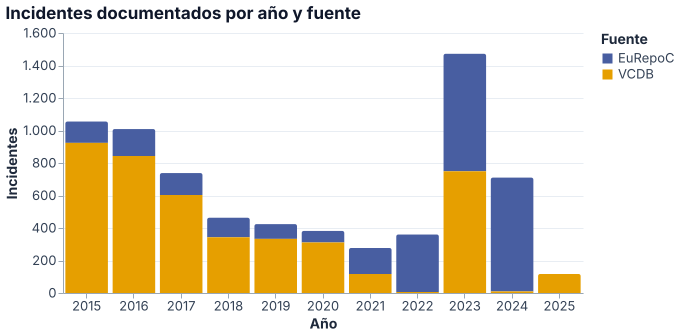

In [20]:
inc_year = incidents.groupby(["year", "source"]).size().reset_index(name="incidents")
alt.Chart(inc_year).mark_bar().encode(
    x=alt.X("year:O", title="Año", axis=alt.Axis(labelAngle=0)),
    y=alt.Y("incidents:Q", title="Incidentes"),
    color=alt.Color("source:N", title="Fuente", scale=alt.Scale(range=theme.CATEGORICAL_COLORS[:2])),
    tooltip=["year:O", "source:N", alt.Tooltip("incidents:Q", format=",")],
).properties(width=520, height=260, title="Incidentes documentados por año y fuente")

### 2.3 Brechas

La métrica de interés es la escala, `pwn_count`. Su distribución está dominada por
unas pocas megabrechas agregadas, con 2019 y 2025 como años récord. La mediana de
cuentas es mucho menor que la media, señal de una fuerte asimetría que condicionará
la codificación (área de burbuja y no longitud). Las clases de datos expuestas más
frecuentes son direcciones de correo y contraseñas.

In [21]:
print(f"Brechas              {len(breaches):>6,}")
print(f"Cuentas expuestas    {breaches['pwn_count'].sum() / 1e9:>6.1f} B")
print(f"Verificadas          {breaches['is_verified'].mean() * 100:>6.1f}%")
print(f"Mediana de cuentas   {breaches['pwn_count'].median():>10,.0f}")
breaches.nlargest(5, "pwn_count")[["title", "year", "sector", "pwn_count"]]

Brechas                 797
Cuentas expuestas      13.4 B
Verificadas            96.6%
Mediana de cuentas      942,044


,title,year,sector,pwn_count
835,Synthient Credential Stuffing Threat Data,2025,Tecnología e información,1957476021
194,Collection #1,2019,Tecnología e información,772904991
926,Verifications.io,2019,Comercio y hostelería,763117241
228,Data Enrichment Exposure From PDL Customer,2019,Medios y entretenimiento,622161052
308,Exploit.In,2016,Tecnología e información,593427119


In [22]:
anual = breaches.groupby("year").agg(brechas=("name", "count"), cuentas_M=("pwn_count", lambda s: round(s.sum() / 1e6)))
print(anual.T.to_string())
print()
print("Clases de datos expuestos más frecuentes")
print(breaches["data_classes"].str.split(";").explode().value_counts().head(8).to_string())

year       2015  2016  2017  2018  2019  2020  2021  2022  2023  2024  2025
brechas      73    99    51    76    80    96    78    61    44    83    56
cuentas_M   421  1697   350  1384  3536  1274   727   191   133  1470  2197

Clases de datos expuestos más frecuentes
data_classes
Email addresses       793
Passwords             535
Names                 437
Usernames             376
IP addresses          318
Phone numbers         287
Dates of birth        228
Physical addresses    222


**Representación individual.** Barras con el eje anclado en cero, el canal correcto
para un importe absoluto (longitud desde cero, Lie Factor de Tufte). Los picos de
2019 y 2025 delatan las megabrechas agregadas que dominan el total.

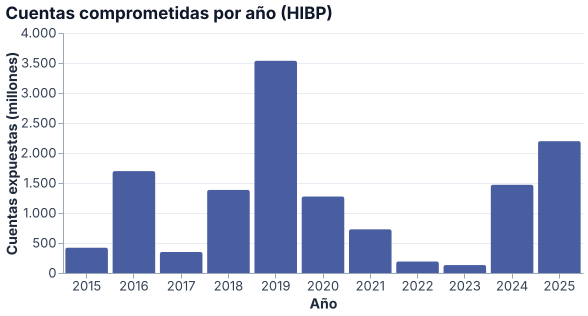

In [23]:
br_year = breaches.groupby("year")["pwn_count"].sum().reset_index()
br_year["millones"] = br_year["pwn_count"] / 1e6
alt.Chart(br_year).mark_bar(color=theme.ACCENT_COLOR).encode(
    x=alt.X("year:O", title="Año", axis=alt.Axis(labelAngle=0)),
    y=alt.Y("millones:Q", title="Cuentas expuestas (millones)"),
    tooltip=["year:O", alt.Tooltip("millones:Q", title="Millones", format=",.0f")],
).properties(width=520, height=240, title="Cuentas comprometidas por año (HIBP)")

### 2.4 Pagos de ransomware

El recuento de pagos y el importe cuentan historias distintas. Hay muchísimos pagos
pequeños y unos pocos enormes, con el bienio 2020-2021 concentrando la mayor parte
del dinero. A nivel de familia, algunas acumulan miles de pagos de pocos cientos de
dólares (extorsión masiva) y otras muy pocos pagos millonarios (caza mayor), una
distinción que separaremos en un gráfico específico.

In [24]:
print(f"Pagos                {len(payments):>8,}")
print(f"Importe total        {payments['amount_usd'].sum() / 1e6:>8,.0f} M USD")
print(f"Pago mediano         {payments['amount_usd'].median():>8,.0f} USD")
print(f"Pago máximo          {payments['amount_usd'].max() / 1e6:>8,.1f} M USD")
payments.groupby("year")["amount_usd"].agg(pagos="count", M_USD=lambda s: round(s.sum() / 1e6, 1)).T

Pagos                  20,939
Importe total           1,015 M USD
Pago mediano              424 USD
Pago máximo              24.8 M USD


year,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
pagos,362.0,11867.0,1604.0,735.0,2870.0,1530.0,1786.0,147.0,19.0,19.0
M_USD,0.1,15.4,2.9,6.1,93.1,379.9,300.8,154.2,13.5,49.0


In [25]:
familias = payments[payments["family"] != "Unlabeled"].groupby("family")["amount_usd"].agg(["count", "sum", "median"])
familias["sum"] = (familias["sum"] / 1e6).round(1)
familias["median"] = familias["median"].round(0)
familias.columns = ["pagos", "M_USD", "pago_mediano_USD"]
familias.nlargest(8, "M_USD")

,pagos,M_USD,pago_mediano_USD
family,,,
Conti,133,101.6,246587.0
Cuba,18,60.2,1073017.0
Netwalker (Mailto),514,27.5,670.0
BlackSuit,3,25.0,180397.0
BlackCat,1,21.9,21867502.0
Locky,10411,14.0,417.0
REvil / Sodinokibi,9,12.1,47778.0
RagnarLocker,9,10.9,58347.0


**Representación individual.** Serie trimestral que suaviza el ruido diario sin
ocultar la ola. El eje temporal continuo y la longitud desde cero sitúan la magnitud
económica del fenómeno.

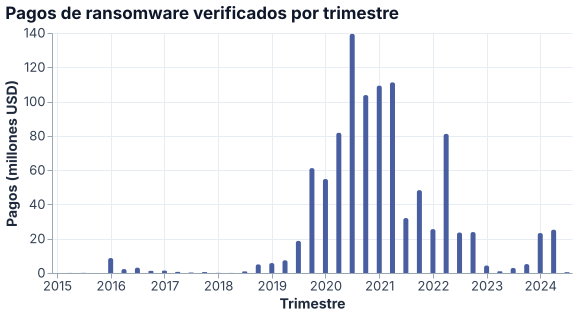

In [26]:
pay_q = payments.set_index("date")["amount_usd"].resample("QS").sum().reset_index()
pay_q["millones"] = pay_q["amount_usd"] / 1e6
alt.Chart(pay_q).mark_bar(color=theme.ACCENT_COLOR).encode(
    x=alt.X("date:T", title="Trimestre", axis=alt.Axis(format="%Y")),
    y=alt.Y("millones:Q", title="Pagos (millones USD)"),
    tooltip=[alt.Tooltip("date:T", format="%Y-%m"), alt.Tooltip("millones:Q", format=",.1f")],
).properties(width=520, height=240, title="Pagos de ransomware verificados por trimestre")

## 3. Selección de fuentes

El enunciado pide definir reglas de selección y filtrado, y no obliga a usar todo lo
explorado. Elegimos siete fuentes porque cada una cubre una perspectiva que las
demás no dan, y descartamos dentro de ellas lo que no aporta al objetivo. El
criterio es la contribución a los subobjetivos y la posibilidad de relacionar clases
entre sí (Tema 1.4.2 y 3.2).

| Fuente | Papel en el análisis | Selección aplicada |
|---|---|---|
| NVD/NIST | Base de vulnerabilidades técnicas | CVEs 2015-2025, sin rechazadas |
| CISA KEV | Enriquece NVD con explotación confirmada | Se une por `cve_id`, no es entidad propia |
| EPSS (FIRST) | Enriquece NVD con probabilidad de explotación | Instantánea actual, unida por `cve_id` |
| VCDB (Verizon) | Incidentes reales, cobertura temprana | Unificado con EuRepoC en una sola entidad |
| EuRepoC | Incidentes con atribución, cobertura reciente | De los cuatro ficheros usamos solo el global 1.3 |
| Have I Been Pwned | Escala de usuarios afectados | Solo brechas genuinas |
| Ransomwhere | Dimensión económica verificada en blockchain | Pagos con marca temporal |

Las subselecciones relevantes son tres. KEV y EPSS entran como enriquecimiento de
NVD y no como tablas independientes, porque su unidad de análisis es la misma CVE.
De EuRepoC, que publica cuatro datasets (global, díadico, atribución y receptor),
tomamos únicamente el global, ya que los otros tres desagregan relaciones que no
necesitamos para el recuento por país y sector. VCDB y EuRepoC se funden en una
única clase de incidente porque describen el mismo objeto con vocabularios
distintos.

Con esta selección el conjunto cumple los mínimos de complejidad del enunciado, más
de cinco clases, más de mil instancias, más de cinco atributos por instancia,
dimensiones espacial y temporal, y varias relaciones entre clases (CVE con KEV, CVE
con EPSS, incidente con país, brecha con sector).

In [27]:
pd.DataFrame({name: {"filas": len(df), "columnas": df.shape[1]} for name, df in data.items()}).T

,filas,columnas
vulnerabilities,241888,16
monthly,855,6
incidents,7007,14
breaches,797,10
payments,20939,5


## 4. Procesado y feature engineering

El procesado genera conceptos más abstractos a partir de los conocidos (Tema 1.2).
Las variables derivadas y las uniones que conectan las fuentes son las siguientes.

- **Banda de severidad** a partir del CVSS, categórica ordinal desde una cuantitativa (Tema 2.2.1).
- **`cvss_imputed`**, marca de trazabilidad de la imputación por CWE.
- **`is_kev` y `kev_ransomware`** por unión NVD con KEV, la explotación real y su uso en ransomware.
- **`epss_score` y `epss_percentile`** por unión NVD con EPSS, la probabilidad estimada.
- **Taxonomía común** de sector y categoría de ataque sobre VCDB y EuRepoC (combinar información, Tema 2.2.2).
- **Códigos ISO 3166** que habilitan el mapa coroplético.
- **Agregado mensual de CVEs** y **resample trimestral de pagos**, reducciones que bajan el grano de dibujo.
- **Sector inferido de HIBP** a partir de texto libre.

La coocurrencia entre dos categóricas se estudia bien con una tabla de contingencia
y se visualiza con un heatmap (Tema 2.2.2). El cruce sector con categoría de ataque
motiva directamente uno de los gráficos posteriores. La interacción entre severidad y
explotación anticipa el argumento de priorización.

In [28]:
print("Interacción severidad × explotación confirmada")
print(pd.crosstab(vuln["cvss_severity"], vuln["is_kev"]).reindex(["LOW", "MEDIUM", "HIGH", "CRITICAL"]).to_string())
print()
print("Coocurrencia sector × categoría de ataque (primeras filas)")
coocc = pd.crosstab(incidents["sector"], incidents["attack_category"])
coocc.loc[coocc.sum(axis=1).sort_values(ascending=False).index].iloc[:6, :6]

Interacción severidad × explotación confirmada
is_kev          False  True 
cvss_severity               
LOW              5238      3
MEDIUM         107528    155
HIGH            93612    746
CRITICAL        34115    491

Coocurrencia sector × categoría de ataque (primeras filas)


attack_category,Desconocido,Disrupción,Error,Físico,Hacking,Hijacking
sector,,,,,,
Administración pública,8,397,262,55,120,177
Salud,7,0,267,131,205,0
Infraestructura crítica y energía,1,241,15,4,37,177
Educación y ciencia,3,1,65,17,694,2
Servicios profesionales,5,37,90,7,148,37
Comercio y hostelería,5,0,51,139,124,0


In [29]:
vuln[["cve_id", "year", "cvss_score", "cvss_severity", "cvss_imputed", "is_kev", "kev_ransomware", "epss_score"]].head(4)

,cve_id,year,cvss_score,cvss_severity,cvss_imputed,is_kev,kev_ransomware,epss_score
0,CVE-2011-5285,2015,4.3,MEDIUM,False,False,False,0.00966
1,CVE-2011-5286,2015,7.5,HIGH,False,False,False,0.03032
2,CVE-2011-5287,2015,4.3,MEDIUM,False,False,False,0.00966
3,CVE-2011-5288,2015,9.3,CRITICAL,False,False,False,0.03803


## 5. Catálogo de visualizaciones combinadas

Reunimos las visualizaciones candidatas que responden a los subobjetivos cruzando
fuentes. Cada una se construye con la misma función de `src/visualization/charts.py`
que consume el dashboard, de modo que lo que se ve aquí es exactamente la figura
integrada, en su variante clara. Para cada gráfico justificamos el tipo según la
clasificación de Oetting (Tema 4.1.2), el canal según el Cuadro 3.1 de Mazza y la
jerarquía de precisión de Cleveland & McGill, el principio de Gestalt que ordena la
lectura y la señalización de escalas o ejes que preserva la honestidad (Lie Factor
de Tufte). Este catálogo es la lluvia de ideas de la que el storytelling seleccionará
y ordenará.

### 5.1 Evolución anual por severidad

**Pregunta 1.** ¿Cómo evolucionan el volumen y la gravedad de las CVEs publicadas?

Evolución temporal (Oetting), resuelta con área apilada. La posición sobre eje común
codifica la magnitud anual, el canal más preciso (Cleveland & McGill), y el área
acumulada transmite el crecimiento del total. La severidad es ordinal de cuatro
niveles y usa el gradiente de severidad, que parte del índigo y vira al cálido en el
extremo crítico ganando croma y luminosidad a la vez (L* 41 → 61). Un tono puro dejaría
las bandas contiguas casi indistinguibles en marcas pequeñas, así que aceptamos la
rotación de tono a cambio de que los cuatro niveles se separen; el orden perceptivo se
mantiene porque la intensidad crece de forma monótona. Eje anclado en cero.

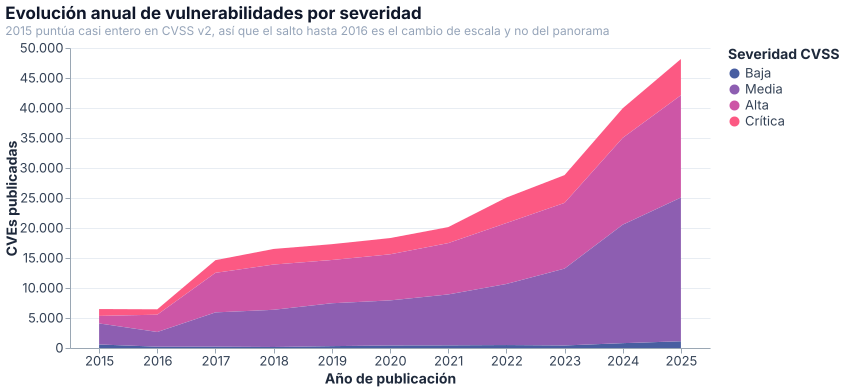

In [30]:
charts.build_temporal_evolution_chart(monthly)

### 5.2 Composición porcentual por severidad

**Pregunta 1** (matiz). ¿Crece la proporción de críticas o solo el total?

Jerarquía parte-todo (Oetting), con área apilada normalizada al cien por cien. Separa
la lectura de la composición de la del volumen y evita el efecto engañoso de los
acumulados en crecimiento. Mantiene la rampa de severidad para que el color actúe de
hilo conductor (similitud, Gestalt).

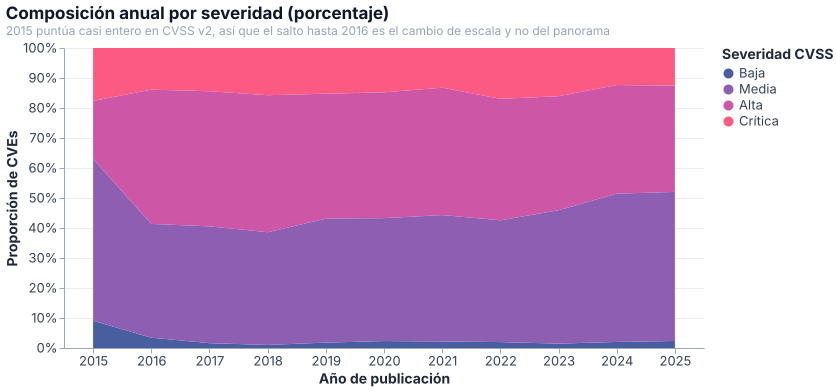

In [31]:
charts.build_severity_share_chart(monthly)

### 5.3 Estacionalidad mensual de publicación

**Pregunta 5.** ¿Existe estacionalidad en la publicación de vulnerabilidades?

Mapa de calor año con mes, que muestra la matriz completa de un vistazo donde doce
líneas superpuestas serían ilegibles (Tema 4.2, heatmap para cruce de dos
categóricas). El conteo es actividad y usa la rampa índigo secuencial de un solo tono,
nunca arcoíris.

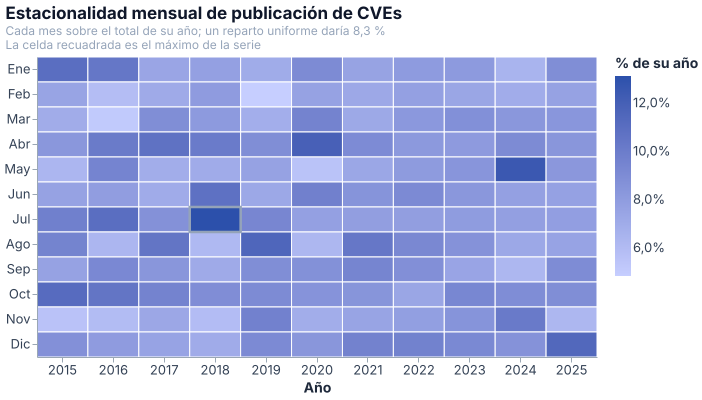

In [32]:
charts.build_seasonality_chart(monthly)

### 5.4 Mapa de incidentes por país

**Pregunta 3.** ¿Dónde se concentra geográficamente la actividad documentada?

Mapa geoespacial (Oetting), coroplético, el estándar cuando la unidad es el país y la
posición geográfica es información implícita del espacio de representación (Tema 3.2).
La rampa índigo de actividad usa transformación logarítmica porque Estados Unidos
concentra la mitad de los casos y una escala lineal dejaría el resto ilegible; el
gris neutro distingue la ausencia de dato del valor bajo.

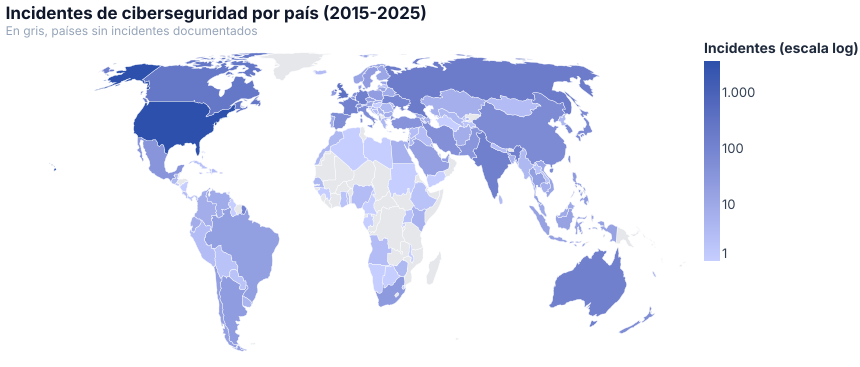

In [33]:
charts.build_geographic_risk_chart(incidents)

### 5.5 Ranking de países

**Pregunta 3** (lectura precisa). El color del mapa es poco preciso; este gráfico da
la comparación exacta.

Comparación de categorías (Oetting), con barras horizontales ordenadas de forma
descendente. Longitud y posición sobre eje común son los canales más precisos
(Cleveland & McGill). Un único color de acento porque solo hay una serie, eje en
cero.

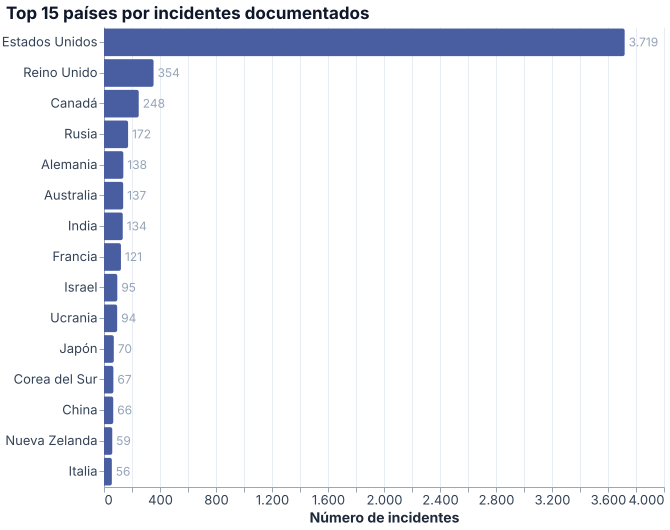

In [34]:
charts.build_top_countries_chart(incidents)

### 5.6 Incidentes por sector y categoría de ataque

**Pregunta 4.** ¿Qué relación existe entre categoría de ataque y sector objetivo?

Conexiones y relaciones (Oetting), con mapa de calor, la representación más eficiente
de un conteo sobre el producto de dos categóricas. Filas y columnas se ordenan por
total descendente para concentrar la masa arriba a la izquierda (proximidad y flujo
de lectura, Gestalt). Rampa índigo en escala logarítmica porque las celdas van de uno a
casi setecientos.

**Advertencia de lectura.** La celda mayor, Educación y ciencia con *hacking*, está dominada por una sola campaña, y la comprobamos abajo antes de interpretarla. VCDB registra una fila por víctima, de modo que una explotación masiva de un producto compartido infla la celda de su sector. No censuramos el dato, lo declaramos (Stikeleather), porque el conteo sigue siendo correcto y lo que cambia es su lectura.

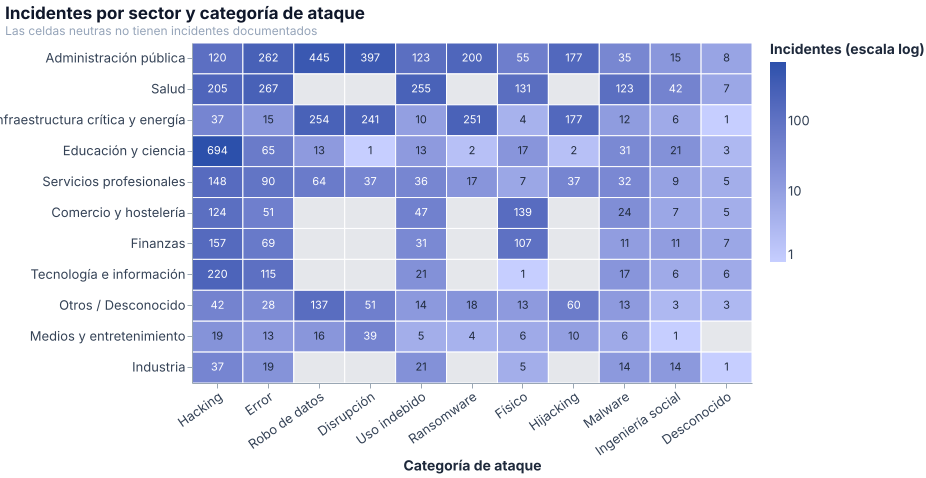

In [35]:
charts.build_sector_attack_heatmap(incidents)

### 5.7 Incidentes por tipo de actor

**Pregunta 3-4** (complemento). ¿Quién inicia los incidentes y cómo cambia con el tiempo?

Evolución temporal con composición, en barras apiladas por año. El tipo de actor es
nominal y se codifica con tono, el canal adecuado para nominales (Mazza), con la
paleta cualitativa de tonos separados, disjunta de las rampas índigo y cálida para no
mezclar semánticas.

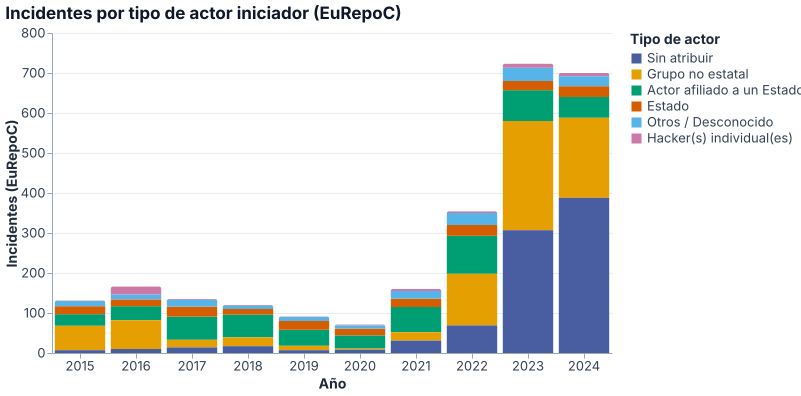

In [36]:
charts.build_actor_type_chart(incidents)

### 5.8 Tipos de debilidad más frecuentes

**Pregunta 2.** ¿Qué debilidades concentran las CVEs y son las más frecuentes también las más graves?

Comparación de categorías (Oetting), con barras horizontales ordenadas. La longitud
codifica la frecuencia y la orientación horizontal deja legibles las etiquetas
largas. El color añade el CVSS medio como segunda variable en el mismo gradiente de
severidad que usan las bandas CVSS, de modo que el significado del color no cambia de
un gráfico a otro; se acepta su menor precisión porque solo señala el contraste
frecuencia con gravedad, no una lectura exacta.

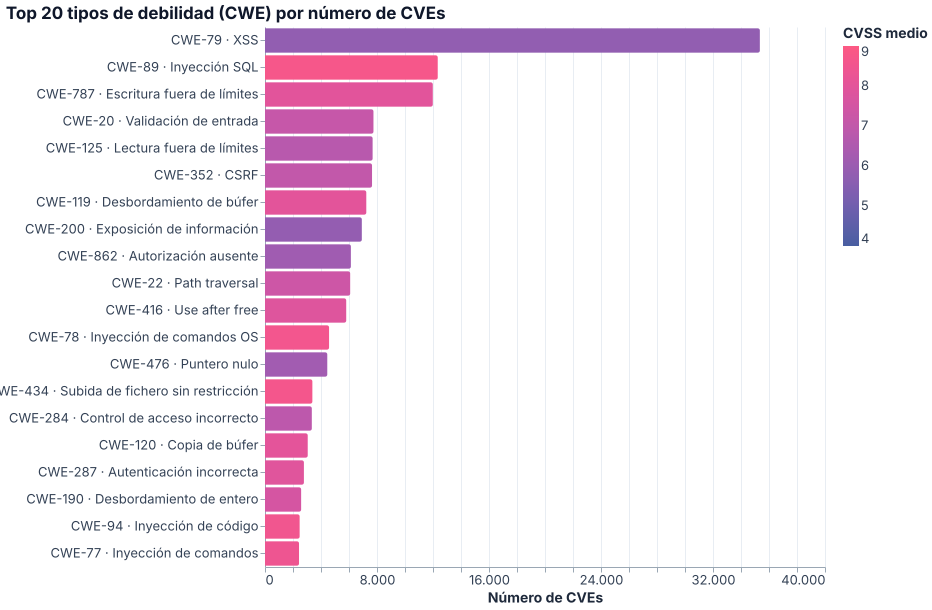

In [37]:
charts.build_cwe_distribution_chart(vuln)

### 5.9 Gravedad frente a probabilidad de explotación

**Pregunta 6.** ¿Coincide la gravedad teórica con la probabilidad y la explotación real?

Conexiones y relaciones (Oetting), con dispersión, el gráfico canónico para dos
cuantitativas. Dibujar 242k puntos saturaría la percepción (Treisman), así que una
muestra fija de 4.000 CVEs no explotadas forma el fondo en gris tenue y las CVEs del
catálogo KEV se dibujan encima en el acento cálido de contraste (figura sobre fondo,
Gestalt), con el uso en ransomware en un tono aún más intenso. El eje EPSS es
logarítmico porque abarca más de tres órdenes de magnitud.

In [38]:
charts.build_cvss_epss_chart(vuln)

### 5.10 Cuentas comprometidas en brechas

**Pregunta 7.** ¿Qué escala de usuarios afectados tiene cada sector y cada año?

Dos paneles de barras, uno por cada mitad de la pregunta, con la magnitud en longitud
sobre eje común, el canal más preciso del cuadro de efectividad de Mazza (Tema 3.1).
Todo lo que el análisis extrae de esta vista es un total, así que el gráfico da
totales. Dos versiones anteriores fallaron por lo mismo: la de burbujas en escala
lineal aplastaba contra el suelo cuatro sectores enteros, y la de puntos por par
sector-año sobre eje logarítmico dejaba los totales para sumarlos a ojo. Entre el
sector más y el menos expuesto median dos órdenes de magnitud, de modo que las barras
pequeñas quedan en muñones; antes que falsear la longitud con una escala logarítmica,
cada barra lleva su cifra.

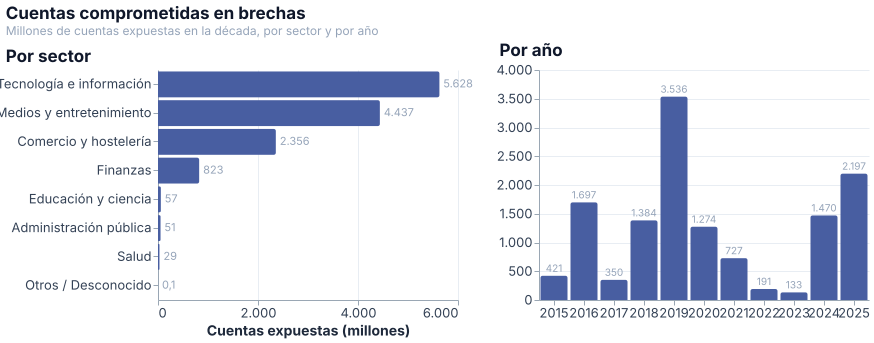

In [39]:
charts.build_breach_pair(breaches)

### 5.11 Pagos de ransomware por trimestre

**Pregunta 8.** ¿Cuál es la dimensión económica del ransomware?

Evolución temporal (Oetting), con barras y eje en cero, la longitud desde cero es el
canal correcto para importes absolutos. La agregación trimestral suaviza el ruido
diario sin ocultar la ola 2019-2021. El detalle va en el tooltip para no sobrecargar.

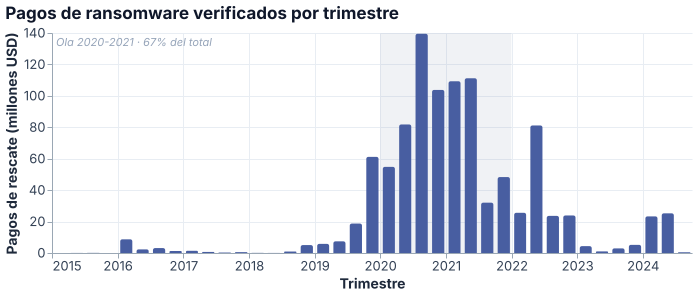

In [40]:
charts.build_ransomware_payments_chart(payments)

### 5.12 Familias de ransomware, pagos frente a recaudación

**Pregunta 8** (desagregación). ¿Extorsión masiva o caza mayor?

Conexiones y relaciones (Oetting), con dispersión en ejes logarítmicos que separa
volumen de pagos y recaudación, dos estrategias criminales distintas. Las etiquetas
van junto a cada punto en lugar de en una leyenda, para lectura inmediata
(proximidad, Gestalt).

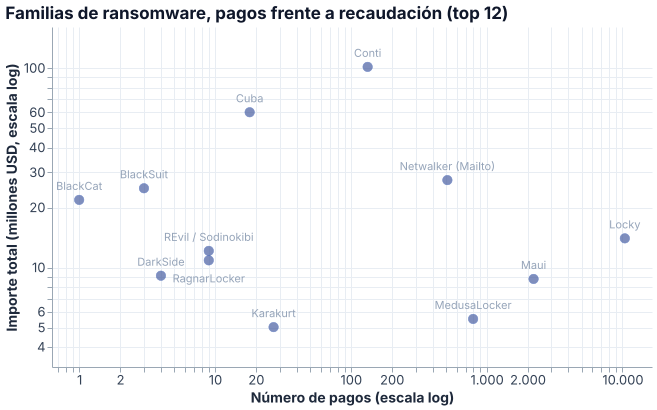

In [41]:
charts.build_ransomware_families_chart(payments)

### 5.13 Incidentes por año y fuente

**Comprobación metodológica**, no una de las doce parciales.

El resto de las vistas de incidentes fusiona VCDB y EuRepoC en una sola serie, donde
un cambio del panorama de amenazas no se distingue de un cambio en lo que los
catálogos documentaron ese año. Barras agrupadas y no apiladas, porque la comparación
que la figura existe para hacer es entre las dos fuentes y no de su total.

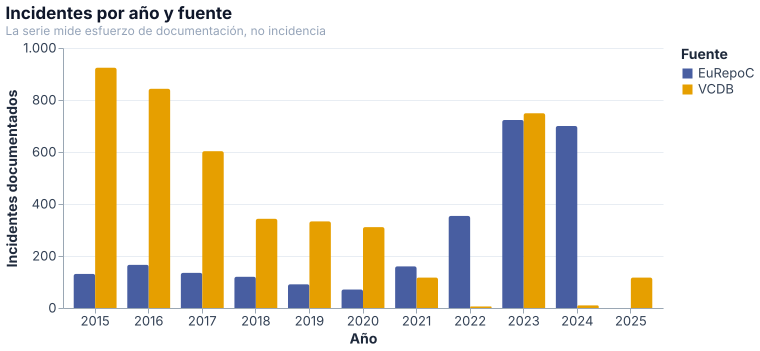

In [42]:
charts.build_incidents_by_source_chart(incidents)

### 5.14 Pares enlazados

Los tres pares con brushing y linking del dashboard también funcionan en el cuaderno,
con el enlace dentro de una misma especificación Vega-Lite, la única forma de
cross-filter sin servidor. Son ejemplos de interactividad funcional orientada a una
pregunta, no decorativa (Tema 1.4.4). El primero, temporal con estacionalidad,
comparte un intervalo de años.

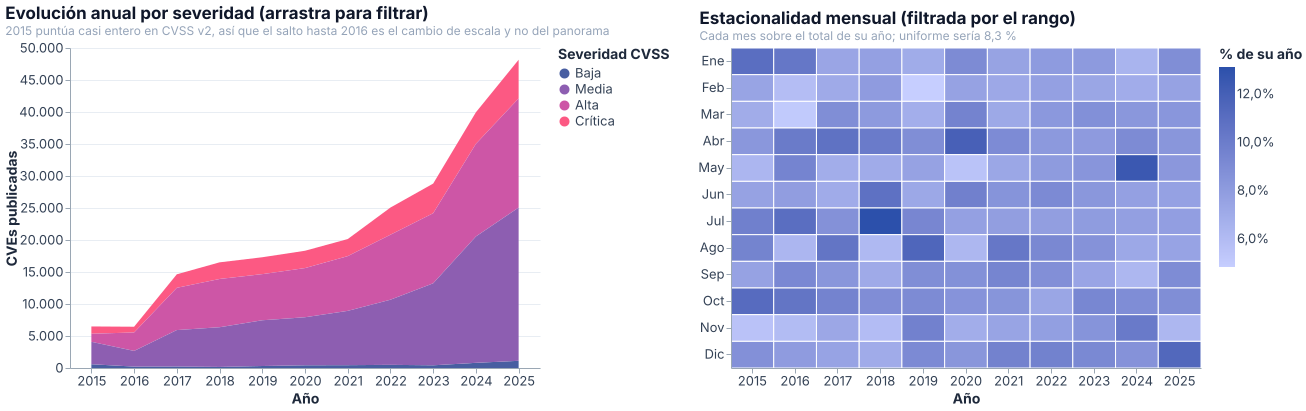

In [43]:
dashboard.build_temporal_pair(monthly)

El segundo par enlaza el heatmap sector con ataque y el mapa. Al elegir un sector en
el heatmap, el mapa colorea cada país con el porcentaje de los incidentes de ese
sector que ocurren allí, es decir, en este sector qué parte pasa en cada país. Es una
normalización a proporción dentro de la selección (Tema 2.2.2), una medida acotada y
comparable que responde de forma directa a la pregunta y evita el problema de la
rampa sobre conteos crudos, donde un país dominante aplasta la escala. El color usa la
rampa índigo de actividad y el mapa arranca con todos los sectores
seleccionados, de modo que se abre sobre el panorama completo y el clic lo
restringe. Al pasar el ratón por un país aparece un bocadillo ampliado con el país,
los incidentes del sector, su porcentaje sobre el total del sector y ese total (detalle
bajo demanda, no decorativo, Tema 1.4.4). El heatmap muestra el número bruto de
incidentes con la rampa índigo, y la opacidad marca el sector activo.

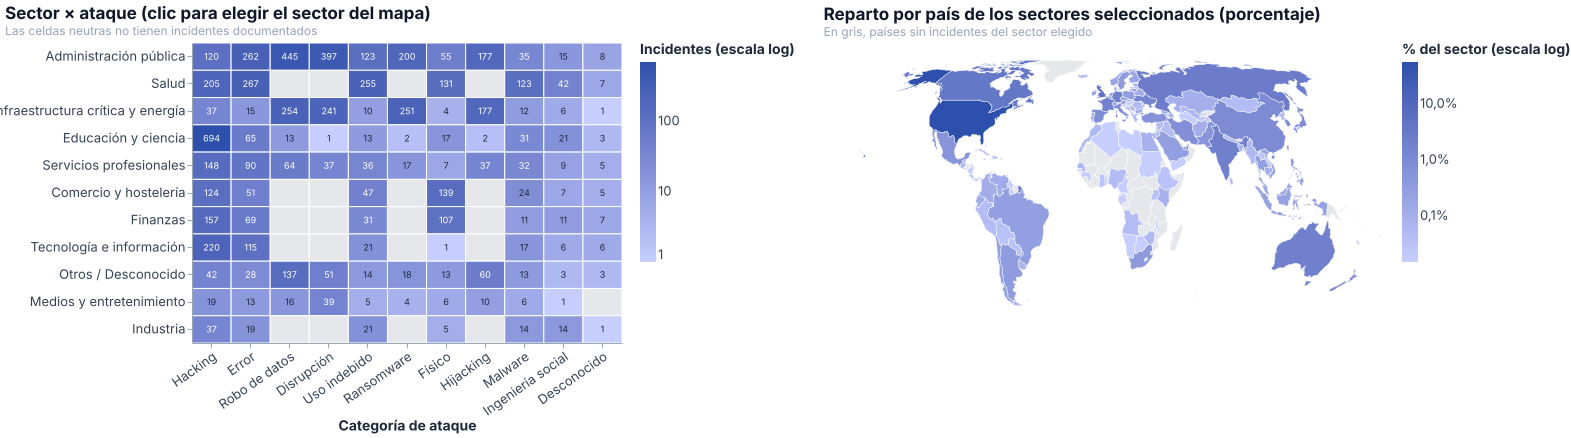

In [44]:
# Mismo par enlazado que integra el dashboard, reutilizado sin duplicar código.
dashboard.build_sector_map_pair(incidents)

El tercero enlaza el ranking de debilidades con el plano de gravedad frente a
explotabilidad. Al hacer clic en una CWE, el plano se queda con sus CVEs, que responde
a la pregunta que las dos vistas plantean por separado: sabido que una debilidad es
frecuente, dónde caen sus vulnerabilidades en gravedad y explotación real.

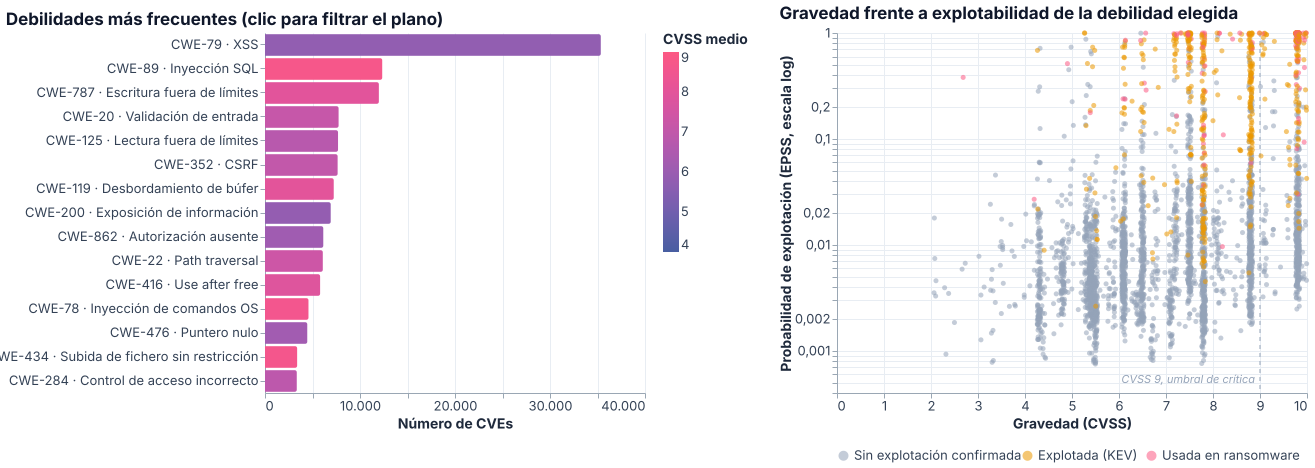

In [45]:
dashboard.build_weakness_pair(vuln)

## 6. Storytelling y diseño del dashboard

Un solo gráfico no basta; hay que crear una estructura superior que guíe al
espectador hacia lo relevante (Tema 3.3). Del catálogo anterior seleccionamos y
ordenamos las vistas en una narrativa de cuatro actos, siguiendo los principios de
Stikeleather, encontrar una narrativa convincente, pensar en la audiencia, ser
objetivo etiquetando ejes y declarando sesgos, y no censurar los datos que no cuadran.

El arco va de lo global a lo específico, el flujo de lectura recomendado para un
cuadro de mando (Tema 4.3.1).

| Acto | Vistas | Pregunta que responde |
|---|---|---|
| 1 La amenaza crece | 5.1, 5.2, 5.3 | ¿Cuánto y qué gravedad, crece la proporción crítica? |
| 2 Dónde golpea y a quién | 5.4, 5.5, 5.6, 5.7 | ¿En qué países y sectores, con qué ataque y qué actor? |
| 3 Qué falla y qué priorizar | 5.8, 5.9 | ¿Qué debilidades y coincide lo grave con lo explotado? |
| 4 El coste | 5.10, 5.11, 5.12 | ¿Qué escala de usuarios y qué dimensión económica? |

La composición aplica los principios de la asignatura (Tema 3.3). La unidad la da la
paleta compartida, con la rampa de severidad como hilo conductor (similitud). La
jerarquía sitúa arriba los indicadores y el titular del crecimiento (dominancia). Los
pares relacionados comparten fila (proximidad) y el contraste de la rampa cálida
sobre el fondo sobrio dirige la atención a la amenaza.

Los indicadores del dashboard se eligen orientados a la decisión, no solo al nivel
(Tema 4.3.1). Cada KPI muestra el delta entre las dos mitades del periodo seleccionado,
convirtiéndolo en señal de tendencia; una ventana anterior de igual duración solo
existe para subrangos, así que comparar mitades es la única regla que da cifra
también en la vista completa. La interactividad responde a
preguntas concretas del público, filtros globales de periodo, severidad, fuente y
sector, y los dos pares enlazados, evitando la interactividad decorativa que impresiona
pero no cumple su propósito (Tema 1.4.4).

Somos objetivos con las limitaciones. VCDB tiene sesgo estadounidense y decae tras
2020, EuRepoC termina en 2024, KEV existe desde finales de 2021, EPSS es una
instantánea y el sector de HIBP es inferido. Por eso las comparaciones entre países
reflejan actividad documentada y no incidencia real, una advertencia que dejamos
escrita en la propia visualización.

Esta sección motiva el diseño del dashboard ya entregado; no lo modifica. Su
ejecución es `make app`.